In [1]:
import nltk
nltk.download('words')
from nltk.corpus import words

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import random
import numpy as np


[nltk_data] Downloading package words to /home/pco0511/nltk_data...
[nltk_data]   Package words is already up-to-date!


## 1.데이터 준비
NLTK corpus (말뭉치) 데이터셋에서 단어를 가져와 처리해준다.


In [2]:
class CharDataset(Dataset):
    """
    NLTK words 코퍼스에서 영문 단어들을 문자 단위로 분할하여
    (입력 시퀀스, 타깃 시퀀스) 쌍으로 구성하는 데이터셋 클래스.
    각 단어는 <s> 시작 토큰과 <e> 종료 토큰으로 감싸며, 추가로 패딩 토큰 <pad>를 사용합니다.

    예: "apple" → 입력: <s> a p p l e, 타깃: a p p l e <e>
    """
    def __init__(self, word_list, max_len=15):
        super().__init__()
        # 1. 단어 리스트 전처리: 알파벳만 포함된 단어, 소문자화, 길이 제한
        self.words = [w.lower() for w in word_list if w.isalpha()]
        self.words = [w for w in self.words if 0 < len(w) <= max_len]

        # 2. 특수 토큰 정의: 패딩, 시작, 종료
        self.special_tokens = ["<pad>", "<s>", "<e>"]  # <pad>:0, <s>:1, <e>:2
        # 단어에 포함된 문자 집합 추출
        chars = set("".join(self.words))
        # 3. 문자-인덱스 사전 생성 (특수 토큰 이후부터 할당)
        self.char2idx = {}
        for i, token in enumerate(self.special_tokens):
            self.char2idx[token] = i
        for i, ch in enumerate(sorted(chars)):
            if ch in self.char2idx:
                continue  # 특수 토큰과 중복되지 않도록
            self.char2idx[ch] = i + len(self.special_tokens)
        self.idx2char = {v: k for k, v in self.char2idx.items()}
        self.vocab_size = len(self.char2idx)

        # 4. (입력, 타깃) 시퀀스 생성
        # 각 단어에 대해: 입력은 <s> + 단어, 타깃은 단어 + <e>
        self.data = []
        for w in self.words:
            input_seq = [self.char2idx["<s>"]] + [self.char2idx[ch] for ch in w]
            target_seq = [self.char2idx[ch] for ch in w] + [self.char2idx["<e>"]]
            self.data.append((input_seq, target_seq))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [3]:
def collate_fn(batch):
    """
    미니배치의 시퀀스 길이가 다르므로, 가장 긴 시퀀스 길이에 맞춰
    입력은 패딩 토큰 (<pad>: 인덱스 0)으로, 타깃은 -100 (CrossEntropyLoss의 ignore_index)으로 패딩합니다.
    """
    input_seqs = [torch.tensor(item[0], dtype=torch.long) for item in batch]
    target_seqs = [torch.tensor(item[1], dtype=torch.long) for item in batch]

    max_len = max(seq.size(0) for seq in input_seqs)

    padded_inputs = []
    padded_targets = []

    for inp, tgt in zip(input_seqs, target_seqs):
        inp_len = inp.size(0)
        tgt_len = tgt.size(0)

        if inp_len < max_len:
            pad_inp = torch.full((max_len - inp_len,), 0, dtype=torch.long)
            inp = torch.cat([inp, pad_inp])
        if tgt_len < max_len:
            pad_tgt = torch.full((max_len - tgt_len,), -100, dtype=torch.long)
            tgt = torch.cat([tgt, pad_tgt])

        padded_inputs.append(inp)
        padded_targets.append(tgt)

    padded_inputs = torch.stack(padded_inputs, dim=0)
    padded_targets = torch.stack(padded_targets, dim=0)

    return padded_inputs, padded_targets

## 2.1. RNN 모델 정의 ToDo1
### ToDo 1. forward 구현하기
x 를 embedding layer를 통해 임베딩 해주고 RNN에 feed forward 해주어 output과 hidden 을 받아준다. 그리고 fc layer에 out 을 통과시켜 최종적으로 logits와 hidden을 return 해준다.

In [4]:
class CharRNN(nn.Module):
    """
    문자 단위 RNN 모델.
    입력: 문자 인덱스 시퀀스 (batch, seq_len)
    출력: 각 시퀀스의 각 타임스텝에 대해 다음 문자에 대한 로짓(logits)
    """
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        """
        x: (batch_size, seq_len)
        hidden: 초기 은닉 상태 (optional)
        """
        #ToDo1
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded,hidden)
        logits = self.fc(out)

        return logits, hidden

## 2.2 LSTM 모델 정의 ToDo2
### ToDo 2. LSTM cell 내부 forward 구현하기


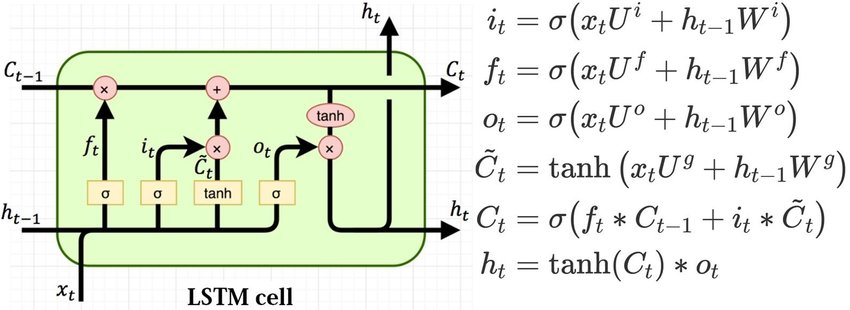

게이트가 4개로 나뉜 뒤 다음 $ \mathbf{C}_t $와 $\mathbf{h}_t$ 를 구하고 각각 h_t_list, c_t_list에 저장해 주는 부분을 구현하면 됩니다.

In [5]:
class LSTMCells(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.W_x = nn.ModuleList([
            nn.Linear(input_dim if i == 0 else hidden_dim, 4 * hidden_dim) for i in range(num_layers)
        ])
        self.W_h = nn.ModuleList([
            nn.Linear(hidden_dim, 4 * hidden_dim) for _ in range(num_layers)
        ])

    def forward(self, x, hidden_state=None):
        batch_size, seq_len, _ = x.shape

        if hidden_state is None:
            h_t = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=x.device)
            c_t = torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=x.device)
        else:
            h_t, c_t = hidden_state

        outputs = []
        h_t_list, c_t_list = [], []  # 새로운 은닉 상태 저장

        for t in range(seq_len):
            x_t = x[:, t, :]

            new_h_t, new_c_t = [], []
            for layer in range(self.num_layers):
                gates = self.W_x[layer](x_t) + self.W_h[layer](h_t[layer])
                f_t, i_t, o_t, g_t = gates.chunk(4, dim=1)
                f_t = torch.sigmoid(f_t)
                i_t = torch.sigmoid(i_t)
                o_t = torch.sigmoid(o_t)
                g_t = torch.tanh(g_t)
                c_next = torch.sigmoid(f_t * c_t[layer] + i_t * g_t)
                h_next = o_t * torch.tanh(c_next)

                new_h_t.append(h_next)
                new_c_t.append(c_next)

                #ToDo2

                x_t = h_next  # 다음 층 입력

            h_t = torch.stack(new_h_t, dim=0)  # 텐서로 변환
            c_t = torch.stack(new_c_t, dim=0)

            outputs.append(h_t[-1].unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)
        return outputs, (h_t, c_t)


class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = LSTMCells(embedding_dim, hidden_dim, num_layers)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        out, hidden = self.lstm(embedded, hidden)
        logits = self.fc(out)
        return logits, hidden


## 3.학습 및 평가 함수

In [6]:
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        # CrossEntropyLoss를 위해 (batch*seq_len, vocab_size) 형태로 변환
        loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs, _ = model(inputs)
            loss = criterion(outputs.view(-1, outputs.size(-1)), targets.view(-1))
            total_loss += loss.item()
    return total_loss / len(dataloader)

## 4.단어 생성 관련 함수

In [7]:
def sample_next_char(model, char_idx, hidden, temperature=1.0, device='cpu'):
    """
    주어진 현재 문자(char_idx)와 은닉 상태를 바탕으로
    다음 문자 인덱스를 확률 샘플링하는 함수.

    Args:
        model: 학습된 RNN 모델.
        char_idx (Tensor): (1, 1) 형태의 현재 문자 인덱스.
        hidden: 현재 은닉 상태.
        temperature (float): 샘플링 온도 (높을수록 무작위성 증가).
        device (str): 'cpu' 또는 'cuda'.

    Returns:
        next_idx (int): 샘플링된 다음 문자 인덱스.
        hidden: 업데이트된 은닉 상태.
    """
    model.eval()
    with torch.no_grad():
        output, hidden = model(char_idx, hidden)  # output: (1, 1, vocab_size)
        logits = output.squeeze(0).squeeze(0)       # (vocab_size)
        scaled_logits = logits / temperature
        probs = torch.softmax(scaled_logits, dim=-1)
        next_idx = torch.multinomial(probs, 1).item()
    return next_idx, hidden


def generate_word(model, dataset, max_len=15, temperature=1.0, device='cpu'):
    """
    단어를 생성하는 함수.
    <s> 토큰에서 시작하여 최대 max_len까지 다음 문자를 샘플링하고,
    종료 토큰(<e>)가 나오면 생성을 종료합니다.

    Args:
        model: 학습된 RNN 모델.
        dataset: CharDataset (문자-인덱스 매핑 포함).
        max_len (int): 생성할 최대 길이 (토큰 수).
        temperature (float): 샘플링 온도.
        device (str): 'cpu' 또는 'cuda'.

    Returns:
        생성된 단어 (문자열, <s>와 <e> 토큰 제외).
    """
    model.eval()
    start_idx = dataset.char2idx["<s>"]
    end_idx = dataset.char2idx["<e>"]
    hidden = None
    # 시작 토큰으로 초기화
    current_char = torch.tensor([[start_idx]], dtype=torch.long).to(device)
    generated_indices = [start_idx]

    for _ in range(max_len):
        next_idx, hidden = sample_next_char(model, current_char, hidden, temperature, device=device)
        generated_indices.append(next_idx)
        current_char = torch.tensor([[next_idx]], dtype=torch.long).to(device)
        if next_idx == end_idx:
            break
    # 시작(<s>) 및 종료(<e>) 토큰 제외하고 문자열 복원
    word = ''.join(dataset.idx2char[idx] for idx in generated_indices if idx not in [start_idx, end_idx])
    return word


def get_next_token_distribution(model, dataset, current_sequence, temperature=1.0, device='cpu'):
    """
    주어진 current_sequence (예: "appl")에 대해 모델이 다음 토큰에 대해 예측하는
    확률 분포를 반환합니다.

    Args:
        model: 학습된 RNN 모델.
        dataset: CharDataset (문자-인덱스 매핑 포함).
        current_sequence (str): 현재까지의 입력 문자열.
        temperature (float): 샘플링 온도.
        device (str): 'cpu' 또는 'cuda'.

    Returns:
        distribution (Tensor): (vocab_size,) 형태의 softmax 확률 분포.
    """
    # <s> 토큰을 포함하여 인덱스 시퀀스로 변환
    indices = [dataset.char2idx["<s>"]]
    for ch in current_sequence:
        if ch in dataset.char2idx:
            indices.append(dataset.char2idx[ch])
        else:
            print(f"경고: '{ch}' 문자는 어휘에 없습니다.")
    input_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs, _ = model(input_tensor)
        last_output = outputs[0, -1]  # 마지막 타임스텝의 로짓
        scaled_logits = last_output / temperature
        distribution = torch.softmax(scaled_logits, dim=-1)
    return distribution


def print_next_token_distribution(model, dataset, current_sequence, temperature=1.0, device='cpu', top_k=10):
    """
    주어진 current_sequence에 대해 모델이 예측한 다음 토큰의 확률 분포 중
    상위 top_k개의 토큰과 확률을 출력합니다.
    """
    distribution = get_next_token_distribution(model, dataset, current_sequence, temperature, device)
    top_probs, top_indices = torch.topk(distribution, top_k)

    print(f"입력: '{current_sequence}' (temperature={temperature})")
    print(f"상위 {top_k} 토큰 분포:")
    for idx, prob in zip(top_indices, top_probs):
        token = dataset.idx2char[idx.item()]
        print(f"  토큰: {token:>4}, 확률: {prob.item():.4f}")
    return distribution


def generate_word_with_prefix(model, dataset, prefix, max_len=15, temperature=1.0, device='cpu'):
    """
    주어진 prefix(프리픽스 문자열)를 시작으로 단어를 생성합니다.
    <s> 토큰을 붙여 프리픽스 전체를 모델에 전달한 후, 마지막 토큰에서부터 생성합니다.

    Args:
        model: 학습된 RNN 모델.
        dataset: CharDataset (문자-인덱스 매핑 포함).
        prefix (str): 생성 시작 프리픽스 (예: "appl").
        max_len (int): 생성할 최대 길이 (전체 토큰 수).
        temperature (float): 샘플링 온도.
        device (str): 'cpu' 또는 'cuda'.

    Returns:
        생성된 단어 (문자열, <s>와 <e> 토큰 제외).
    """
    model.eval()
    start_token = "<s>"
    end_token = "<e>"
    start_idx = dataset.char2idx[start_token]
    end_idx = dataset.char2idx[end_token]

    # 프리픽스 인덱스: <s> + 프리픽스의 각 문자
    indices = [start_idx]
    for ch in prefix:
        if ch in dataset.char2idx:
            indices.append(dataset.char2idx[ch])
        else:
            print(f"경고: '{ch}' 문자는 어휘에 없습니다. 무시합니다.")

    # 프리픽스 전체(마지막 토큰 제외)를 모델에 전달하여 은닉 상태 업데이트
    if len(indices) > 1:
        input_tensor = torch.tensor(indices[:-1], dtype=torch.long).unsqueeze(0).to(device)
        with torch.no_grad():
            _, hidden = model(input_tensor)
    else:
        input_tensor = torch.tensor([indices], dtype=torch.long).to(device)
        hidden = None

    # 프리픽스의 마지막 토큰을 현재 입력으로 설정하여 이후 토큰 생성
    current_token = torch.tensor([[indices[-1]]], dtype=torch.long).to(device)
    generated_indices = indices.copy()

    for _ in range(max_len - len(indices)):
        next_idx, hidden = sample_next_char(model, current_token, hidden, temperature, device=device)
        generated_indices.append(next_idx)
        current_token = torch.tensor([[next_idx]], dtype=torch.long).to(device)
        if next_idx == end_idx:
            break
    # 시작(<s>) 및 종료(<e>) 토큰 제외하고 문자열 복원
    word = ''.join(dataset.idx2char[idx] for idx in generated_indices if idx not in [start_idx, end_idx])
    return word

## 5.훈련 및 실행

In [9]:
def main(model_type):
    # 재현성을 위한 시드 설정
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Running on:", device)

    # NLTK words 코퍼스 다운로드 (최초 실행 시)
    nltk.download('words')
    word_list = words.words()

    # 데이터셋 및 DataLoader 준비
    max_word_len = 32  # 단어 최대 길이 (특수 토큰 제외)
    dataset = CharDataset(word_list, max_len=max_word_len)

    # train/validation 분할
    train_size = int(0.8 * len(dataset.data))
    valid_size = len(dataset.data) - train_size
    train_dataset, valid_dataset = torch.utils.data.random_split(dataset, [train_size, valid_size])

    batch_size = 1024
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # 모델, 옵티마이저, 손실함수 정의
    if model_type == "LSTM":
        model = CharLSTM(vocab_size=dataset.vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2).to(device)
    elif model_type == "RNN":
        model = CharRNN(vocab_size=dataset.vocab_size, embedding_dim=64, hidden_dim=256, num_layers=2).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=0.004, weight_decay=0.1)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)  # 패딩된 타깃 무시

    # 학습 루프
    epochs = 100
    for epoch in range(1, epochs + 1):
        train_loss = train(model, train_loader, optimizer, criterion, device)
        valid_loss = evaluate(model, valid_loader, criterion, device)
        print(f"Epoch [{epoch}/{epochs}] | Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")

    # 무작위 단어 생성 테스트
    print("\n[무작위 단어 생성]")
    for _ in range(10):
        generated_word = generate_word(model, dataset, max_len=max_word_len, temperature=0.3, device=device)
        print(generated_word)

    # 특정 입력에 대한 다음 토큰 분포 확인
    test_sequence = "app"
    print("\n[다음 토큰 분포 확인]")
    print_next_token_distribution(model, dataset, test_sequence, temperature=1.0, device=device, top_k=10)

    # 프리픽스 기반 단어 생성 테스트
    prefix = "app"
    print(f"\n[프리픽스 '{prefix}'로 생성된 단어]")
    generated_set = set()
    for _ in range(20):
        generated = generate_word_with_prefix(model, dataset, prefix, max_len=max_word_len, temperature=0.3, device=device)
        if generated in generated_set:
            continue
        generated_set.add(generated)
        print(generated)


if __name__ == "__main__":
    main("RNN")
    main("LSTM")

Running on: cuda


[nltk_data] Downloading package words to /home/pco0511/nltk_data...
[nltk_data]   Package words is already up-to-date!


Epoch [1/100] | Train Loss: 2.1931 | Valid Loss: 2.0032
Epoch [2/100] | Train Loss: 1.9456 | Valid Loss: 1.9080
Epoch [3/100] | Train Loss: 1.8759 | Valid Loss: 1.8642
Epoch [4/100] | Train Loss: 1.8364 | Valid Loss: 1.8406
Epoch [5/100] | Train Loss: 1.8107 | Valid Loss: 1.8203
Epoch [6/100] | Train Loss: 1.7920 | Valid Loss: 1.8112
Epoch [7/100] | Train Loss: 1.7780 | Valid Loss: 1.7997
Epoch [8/100] | Train Loss: 1.7659 | Valid Loss: 1.7933
Epoch [9/100] | Train Loss: 1.7580 | Valid Loss: 1.7886
Epoch [10/100] | Train Loss: 1.7499 | Valid Loss: 1.7852
Epoch [11/100] | Train Loss: 1.7439 | Valid Loss: 1.7869
Epoch [12/100] | Train Loss: 1.7386 | Valid Loss: 1.7819
Epoch [13/100] | Train Loss: 1.7339 | Valid Loss: 1.7788
Epoch [14/100] | Train Loss: 1.7299 | Valid Loss: 1.7769
Epoch [15/100] | Train Loss: 1.7267 | Valid Loss: 1.7780
Epoch [16/100] | Train Loss: 1.7243 | Valid Loss: 1.7743
Epoch [17/100] | Train Loss: 1.7205 | Valid Loss: 1.7673
Epoch [18/100] | Train Loss: 1.7186 | Va

[nltk_data] Downloading package words to /home/pco0511/nltk_data...
[nltk_data]   Package words is already up-to-date!


Epoch [1/100] | Train Loss: 2.4940 | Valid Loss: 2.2641
Epoch [2/100] | Train Loss: 2.1947 | Valid Loss: 2.1336
Epoch [3/100] | Train Loss: 2.1027 | Valid Loss: 2.0750
Epoch [4/100] | Train Loss: 2.0491 | Valid Loss: 2.0347
Epoch [5/100] | Train Loss: 2.0130 | Valid Loss: 1.9994
Epoch [6/100] | Train Loss: 1.9877 | Valid Loss: 1.9787
Epoch [7/100] | Train Loss: 1.9652 | Valid Loss: 1.9601
Epoch [8/100] | Train Loss: 1.9505 | Valid Loss: 1.9441
Epoch [9/100] | Train Loss: 1.9365 | Valid Loss: 1.9349
Epoch [10/100] | Train Loss: 1.9249 | Valid Loss: 1.9259
Epoch [11/100] | Train Loss: 1.9140 | Valid Loss: 1.9135
Epoch [12/100] | Train Loss: 1.9059 | Valid Loss: 1.9036
Epoch [13/100] | Train Loss: 1.8981 | Valid Loss: 1.9027
Epoch [14/100] | Train Loss: 1.8928 | Valid Loss: 1.8918
Epoch [15/100] | Train Loss: 1.8860 | Valid Loss: 1.8912
Epoch [16/100] | Train Loss: 1.8816 | Valid Loss: 1.8884
Epoch [17/100] | Train Loss: 1.8773 | Valid Loss: 1.8877
Epoch [18/100] | Train Loss: 1.8734 | Va